In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from sklearn.decomposition import PCA

In [ ]:
full_path = r"Reizman_database - COMPLETE - BASELINE.xlsx"
df = pd.read_excel(full_path)

In [ ]:
fukk_path_datavis = r"Reizman_database - DATAVIS.xlsx"
df_datavis = pd.read_excel(fukk_path_datavis)

##### Data analytics

C:\Users\livio\AppData\Local\Temp\ipykernel_18932\2287262735.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df["yield_pct"], bins=30, edgecolor="0.2", linewidth=0.8, palette="deep", kde=True)


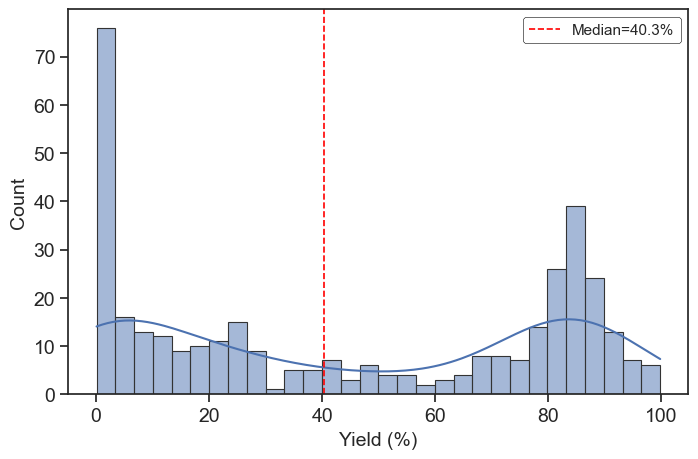

In [ ]:
# Yield distribution
sns.set_theme(style="ticks")
sns.color_palette()
f, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["yield_pct"], bins=30, edgecolor="0.2", linewidth=0.8, palette="deep", kde=True)
ax.axvline(df["yield_pct"].median(), color="red", linestyle="--", linewidth=1.2, label=f"Median={df['yield_pct'].median():.1f}%")
# ax.set_title("Yield Distribution")
ax.set_xlabel("Yield (%)", fontsize=14)
ax.set_ylabel("Count", fontsize=14)
ax.tick_params(axis='both', labelsize=14)
legend = ax.legend(
    facecolor='white',      # Solid white background
    edgecolor='black',      # Black border
    framealpha=1,           # Fully opaque
    fancybox=True,          # Rounding of the box
)
legend.get_frame().set_linewidth(0.4) # Changing the thickness of the border
# plt.savefig('Reizman-Yield-Count.pdf', dpi=600, bbox_inches='tight')

C:\Users\livio\AppData\Local\Temp\ipykernel_18932\255197123.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_datavis, x="catalyst", y="yield_pct",


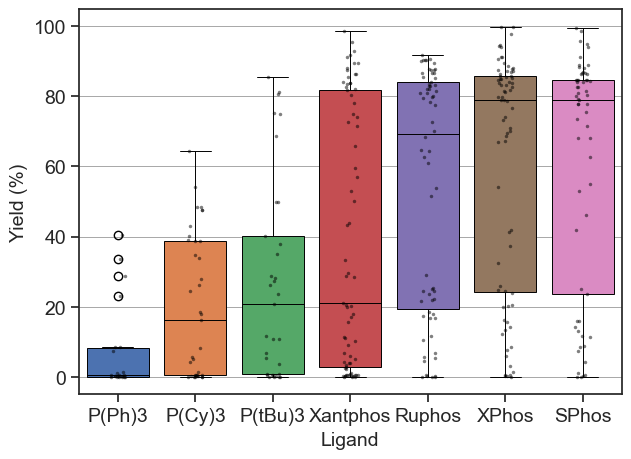

In [ ]:
# Yield by catalyst
median_order = df_datavis.groupby("catalyst")["yield_pct"].median().sort_values().index.tolist()
f, ax = plt.subplots(figsize=(7, 5))
order = sorted(df_datavis["catalyst"].unique())
sns.boxplot(data=df_datavis, x="catalyst", y="yield_pct", 
            linewidth=0.7, palette="deep", 
            saturation=1, linecolor="black", order=median_order)
sns.stripplot(data=df_datavis, x="catalyst", y="yield_pct", color="black", alpha=0.5, size=2.5)
# ax.set_title("Yield distribution by catalyst", fontsize=14)
ax.set_ylabel("Yield (%)", fontsize=14)
ax.set_xlabel("Ligand", fontsize=14)
ax.tick_params(axis='both', labelsize=14)
ax.grid(True, axis="y", linewidth=0.6, color="black", alpha=0.4)
# plt.savefig('Reizman-Yield-Catalyst.pdf', dpi=600,  bbox_inches='tight')

C:\Users\livio\AppData\Local\Temp\ipykernel_18932\2521738772.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="case", y="yield_pct",


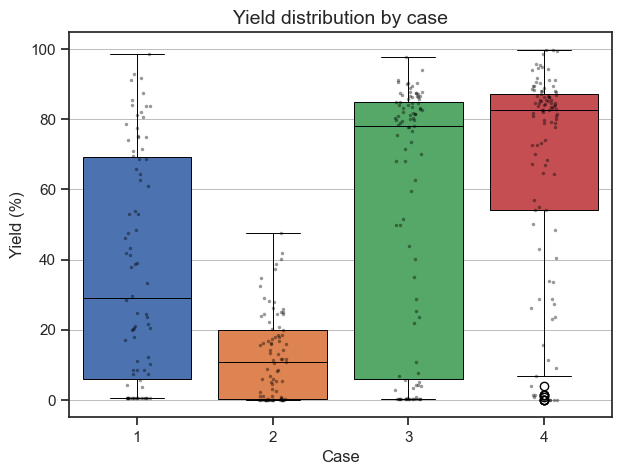

In [7]:
# Yield by case
f, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="case", y="yield_pct", 
            linewidth=0.7, palette="deep", 
            saturation=1, linecolor="black")
sns.stripplot(data=df, x="case", y="yield_pct", color="black", alpha=0.4, size=2.5)
ax.set_title("Yield distribution by case", fontsize=14)
ax.set_ylabel("Yield (%)")
ax.set_xlabel("Case")
ax.grid(True, axis="y", linewidth=0.6, color="black", alpha=0.3)

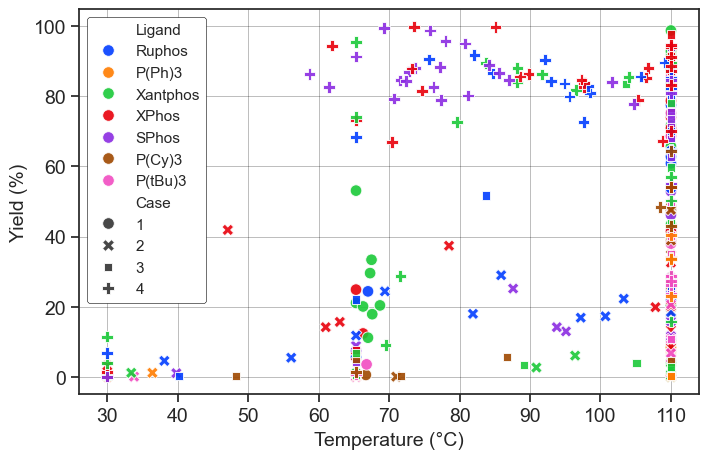

In [ ]:
# Yield against temperature
df_datavis = df_datavis.rename(columns={"catalyst": "Ligand"})
df_datavis = df_datavis.rename(columns={"case": "Case"})
sns.set_theme(style="ticks")
f, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df_datavis, x="temp_c", y="yield_pct", hue="Ligand", style="Case", alpha=0.9, palette="bright", s=70)
# ax.set_title("Yield vs Temperature", fontsize=14)
ax.set_ylabel("Yield (%)", fontsize=14)
ax.set_xlabel("Temperature (°C)", fontsize=14)
ax.grid(True, axis="both", linewidth=0.6, color="black", alpha=0.3)
ax.tick_params(axis='both', labelsize=14)
legend = ax.legend(
    facecolor='white',      # Solid white background
    edgecolor='black',      # Black border
    framealpha=1,           # Fully opaque
    fancybox=True,          # Rounding of the box
)
legend.get_frame().set_linewidth(0.4) # Changing the thickness of the border
# plt.savefig('Reizman-Yield-Temperate-Case.pdf', dpi=600,  bbox_inches='tight')

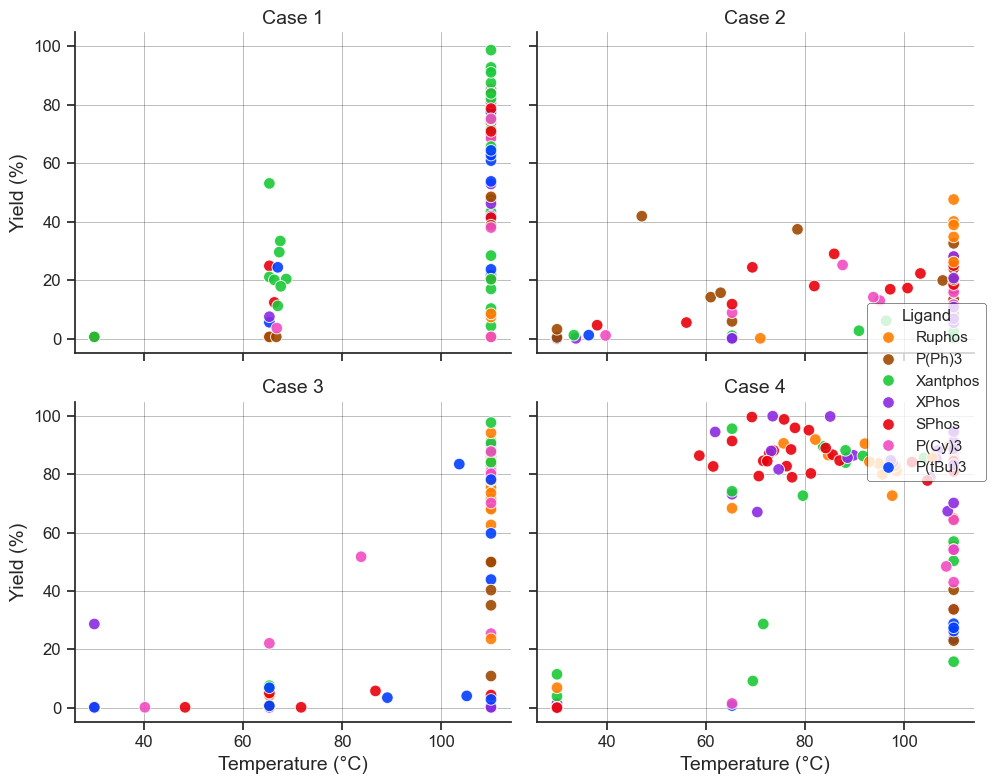

In [17]:
sns.set_theme(style="ticks")

g = sns.FacetGrid(
    df_datavis,
    col="Case",
    col_wrap=2,           # 2x2 grid for 4 cases
    height=4,
    aspect=1.1,
    sharey=True,          # same y-axis across panels for easy comparison
    sharex=True
)

g.map_dataframe(
    sns.scatterplot,
    x="temp_c",
    y="yield_pct",
    hue="Ligand",
    palette="bright",
    alpha=0.9,
    s=70,
    data=df_datavis
)

# Add a shared legend outside the grid
g.add_legend(
    title="Ligand",
    frameon=True,
    facecolor="white",
    edgecolor="black",
)
g.legend.get_frame().set_linewidth(0.4)

# Axis labels and grid per panel
g.set_axis_labels("Temperature (°C)", "Yield (%)", fontsize=14)
g.set_titles(col_template="Case {col_name}", size=14)
for ax in g.axes.flat:
    ax.grid(True, axis="both", linewidth=0.6, color="black", alpha=0.3)
    ax.tick_params(axis="both", labelsize=12)

plt.tight_layout()

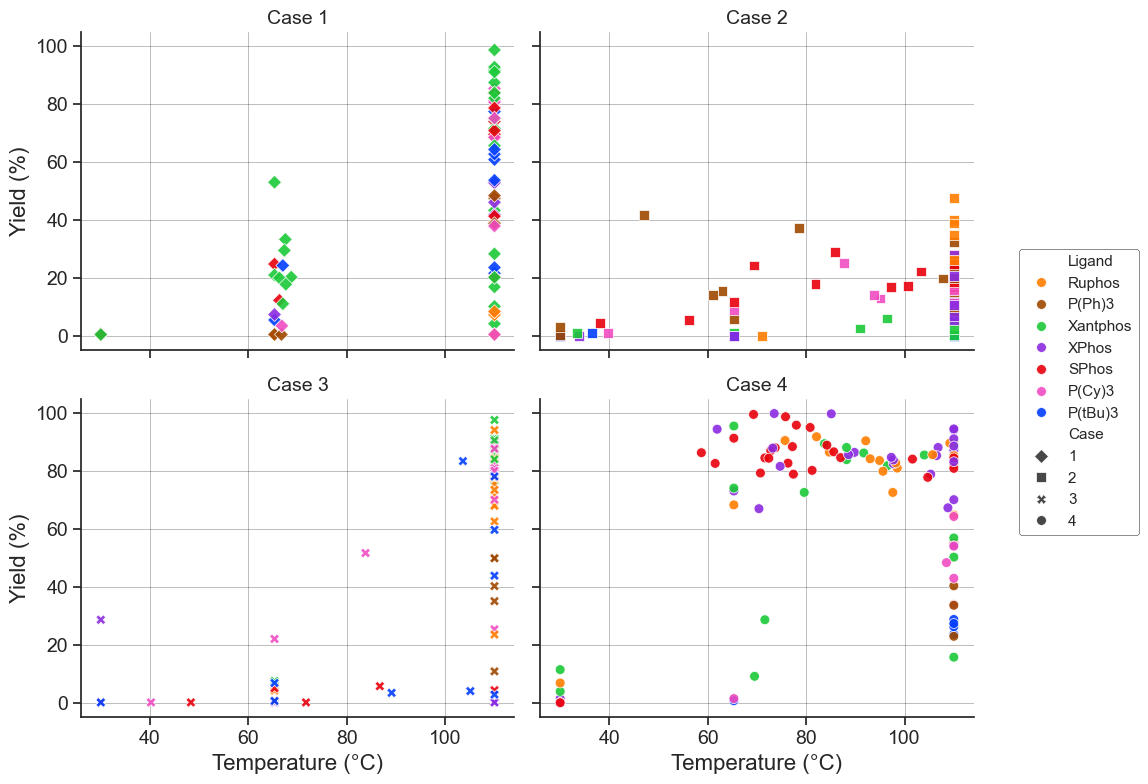

In [41]:
sns.set_theme(style="ticks")

# Define markers per case
case_markers = {1: "D", 2: "s", 3: "X", 4: "o"}  # circle, square, cross, diamond

g = sns.FacetGrid(
    df_datavis,
    col="Case",
    col_wrap=2,
    height=4,
    aspect=1.1,
    sharey=True,
    sharex=True
)

g.map_dataframe(
    sns.scatterplot,
    x="temp_c",
    y="yield_pct",
    hue="Ligand",
    style="Case",
    markers=case_markers,
    palette="bright",
    alpha=0.9,
    s=50,
)

# --- Legend placement ---
# Option A: inside a specific axis (e.g. top-right of first panel)
# g.axes[0].legend(
#     title="Ligand",
#     loc="upper left",       # change to "upper right", "lower right", etc.
#     frameon=True,
#     facecolor="white",
#     edgecolor="black",
# ).get_frame().set_linewidth(0.4)

# Option B: outside the grid entirely — comment out Option A and use this instead
g.add_legend(
    bbox_to_anchor=(1.02, 0.5),  # (x, y) in figure coordinates
    loc="center left",            # anchor point of the legend box
    frameon=True,
    facecolor="white",
    edgecolor="black",
)
g.legend.get_frame().set_linewidth(0.4)

g.set_axis_labels("Temperature (°C)", "Yield (%)", fontsize=16)
g.set_titles(col_template="Case {col_name}", size=14)
for ax in g.axes.flat:
    ax.grid(True, axis="both", linewidth=0.6, color="black", alpha=0.3)
    ax.tick_params(axis="both", labelsize=14)

plt.tight_layout()

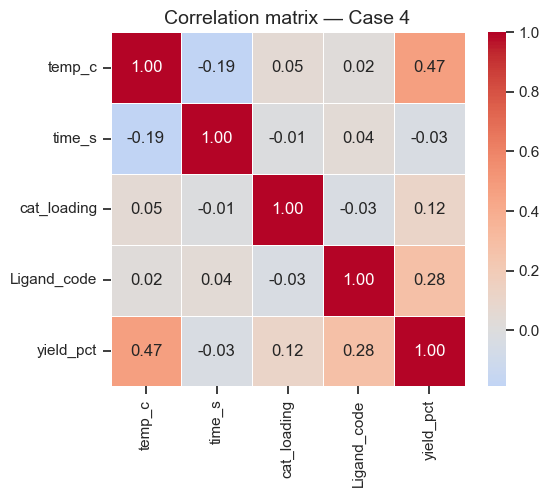

In [48]:
df_case4 = df_datavis[df_datavis["Case"] == 4].copy()

# Encode ligand as numeric for correlation
df_datavis["Ligand_code"] = df_datavis["Ligand"].astype("category").cat.codes

corr = df_datavis[["temp_c", "time_s", "cat_loading", "Ligand_code", "yield_pct"]].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Correlation matrix — Case 4", fontsize=14)
plt.tight_layout()

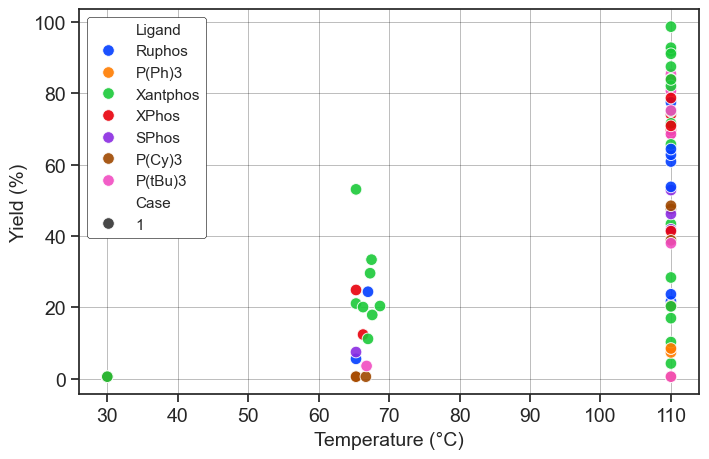

In [16]:
df_datavis_case1 = df_datavis[df_datavis["Case"] == 1]
sns.set_theme(style="ticks")
f, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df_datavis_case1, x="temp_c", y="yield_pct", hue="Ligand", style="Case", alpha=0.9, palette="bright", s=70)
# ax.set_title("Yield vs Temperature", fontsize=14)
ax.set_ylabel("Yield (%)", fontsize=14)
ax.set_xlabel("Temperature (°C)", fontsize=14)
ax.grid(True, axis="both", linewidth=0.6, color="black", alpha=0.3)
ax.tick_params(axis='both', labelsize=14)
legend = ax.legend(
    facecolor='white',      # Solid white background
    edgecolor='black',      # Black border
    framealpha=1,           # Fully opaque
    fancybox=True,          # Rounding of the box
)
legend.get_frame().set_linewidth(0.4) # Changing the thickness of the border

Text(54.75, 0.5, 'Catalyst')

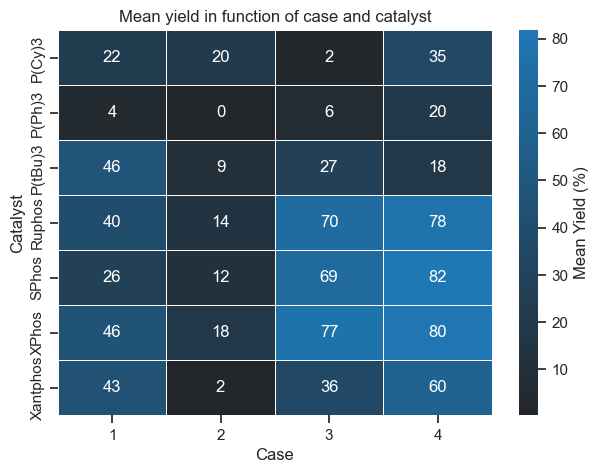

In [15]:
# TEST
f, ax = plt.subplots(figsize=(7, 5))
custom_pallete = sns.color_palette("dark:#1f77b4", as_cmap=True)
pivot = df_datavis.pivot_table(values="yield_pct", index="Ligand", columns="Case", aggfunc="mean")
sns.heatmap(pivot, annot=True, fmt=".0f", cmap=custom_pallete, linewidths=0.5, cbar_kws={"label": "Mean Yield (%)"})
ax.set_title("Mean yield in function of case and catalyst")
ax.set_xlabel("Case")
ax.set_ylabel("Catalyst")

Text(54.75, 0.5, 'Catalyst')

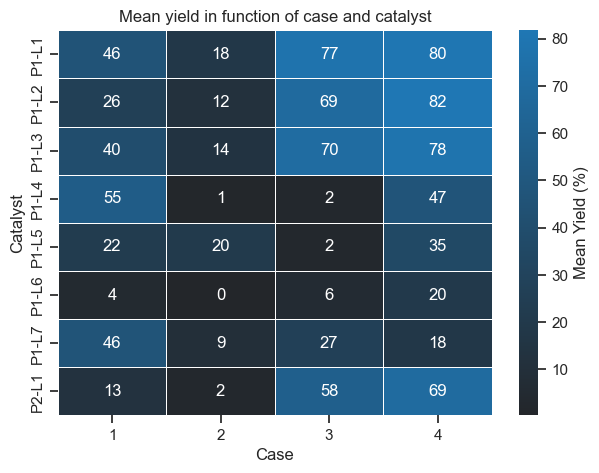

In [8]:
# Mean yield for different cases and catalyst as a heatmap
f, ax = plt.subplots(figsize=(7, 5))
custom_pallete = sns.color_palette("dark:#1f77b4", as_cmap=True)
pivot = df.pivot_table(values="yield_pct", index="catalyst", columns="case", aggfunc="mean")
sns.heatmap(pivot, annot=True, fmt=".0f", cmap=custom_pallete, linewidths=0.5, cbar_kws={"label": "Mean Yield (%)"})
ax.set_title("Mean yield in function of case and catalyst")
ax.set_xlabel("Case")
ax.set_ylabel("Catalyst")